In [1]:
import pandas as pd
df0= pd.read_csv(r"C:\Users\pushp\Result_800\2_0.csv")
df1= pd.read_csv(r"C:\Users\pushp\Result_800\2_1.csv")
df2= pd.read_csv(r"C:\Users\pushp\Result_800\2_2.csv")
df3= pd.read_csv(r"C:\Users\pushp\Result_800\2_3.csv")
df4= pd.read_csv(r"C:\Users\pushp\Result_800\2_4.csv")
df5= pd.read_csv(r"C:\Users\pushp\Result_800\2_5.csv")
df6= pd.read_csv(r"C:\Users\pushp\Result_800\2_6.csv")
df7= pd.read_csv(r"C:\Users\pushp\Result_800\2_7.csv")
df8= pd.read_csv(r"C:\Users\pushp\Result_800\2_8.csv")
df9= pd.read_csv(r"C:\Users\pushp\Result_800\2_9.csv")
dfs= [df0,df1, df2, df3, df4, df5, df6, df7, df8, df9]
merged_df= pd.concat(dfs, ignore_index= True)

In [7]:
merged_df.to_excel(r'C:\Users\pushp\Result_800\merged_output.xlsx', index=False)

In [2]:
!pip install torch

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install pyDOE

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for pyDOE: filename=pyDOE-0.3.8-py3-none-any.whl size=18198 sha256=4660506b732936f42c3ab020904435cedf38ec38a32916ceb62e3b446bd24b8a
  Stored in directory: c:\users\pushp\appdata\local\pip\cache\wheels\96\b9\5d\1138ea8c8f212bce6e97ae58847b7cc323145b3277f2129e2b
Successfully built pyDOE


In [12]:
# Physics-Informed Neural Network for 3D Heat & Fluid Dynamics using PyTorch
# Pretrain on Excel data; maintrain using PDEs only (no boundary/initial conditions)

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from pyDOE import lhs

# Define neural network
class FCNN(nn.Module):
    def __init__(self, layers):
        super(FCNN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
        self.activation = nn.Tanh()

    def forward(self, x):
        for i in range(len(self.layers) - 1):
            x = self.activation(self.layers[i](x))
        return self.layers[-1](x)

# Define the PINN model
class PINN3D:
    def __init__(self, X_data, Y_data, X_f, layers, lb, ub):
        self.lb = torch.tensor(lb, dtype=torch.float32)
        self.ub = torch.tensor(ub, dtype=torch.float32)

        self.X_data = torch.tensor(X_data, dtype=torch.float32)
        self.Y_data = torch.tensor(Y_data, dtype=torch.float32)
        self.X_f = torch.tensor(X_f, dtype=torch.float32)

        self.model = FCNN(layers)

        self.optimizer_pre = torch.optim.Adam(self.model.parameters(), lr=1e-3)
        self.optimizer_main = torch.optim.Adam(self.model.parameters(), lr=1e-3)

    def net_Y(self, X):
        X_norm = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
        return self.model(X_norm)

    def net_f(self, X):
        X.requires_grad_(True)
        Y = self.net_Y(X)
        T, vx, vy, vz, P = torch.split(Y, 1, dim=1)

        x, y, z, t = torch.split(X, 1, dim=1)
        P_laser, eta, rb, Vs = 150, 0.3, 50e-6, 0.01
        Q = (2*P_laser*eta/(np.pi*rb**2)) * torch.exp(-2*((x - Vs*t)**2 + y**2)/(rb**2))

        rho = 7800.0
        mu = 0.006
        cp = 500.0
        kappa = 25.0
        L = 2.5e5
        Ts, Tl = 1600.0, 1700.0

        fL = torch.clamp((T - Ts)/(Tl - Ts), 0.0, 1.0)

        grads = lambda y, x: torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y),
                                                 retain_graph=True, create_graph=True)[0]

        dvx_dx = grads(vx, x)
        dvx_dy = grads(vx, y)
        dvx_dz = grads(vx, z)
        dvx_dt = grads(vx, t)

        dvy_dx = grads(vy, x)
        dvy_dy = grads(vy, y)
        dvy_dz = grads(vy, z)
        dvy_dt = grads(vy, t)

        dvz_dx = grads(vz, x)
        dvz_dy = grads(vz, y)
        dvz_dz = grads(vz, z)
        dvz_dt = grads(vz, t)

        dP_dx = grads(P, x)
        dP_dy = grads(P, y)
        dP_dz = grads(P, z)

        dT_dx = grads(T, x)
        dT_dy = grads(T, y)
        dT_dz = grads(T, z)
        dT_dt = grads(T, t)

        dfL_dx = grads(fL, x)
        dfL_dy = grads(fL, y)
        dfL_dz = grads(fL, z)
        dfL_dt = grads(fL, t)

        lap_T = dT_dx**2 + dT_dy**2 + dT_dz**2
        div_u = dvx_dx + dvy_dy + dvz_dz

        mom_x = rho * (dvx_dt + vx*dvx_dx + vy*dvx_dy + vz*dvx_dz) - dP_dx - mu * lap_T
        mom_y = rho * (dvy_dt + vx*dvy_dx + vy*dvy_dy + vz*dvy_dz) - dP_dy - mu * lap_T
        mom_z = rho * (dvz_dt + vx*dvz_dx + vy*dvz_dy + vz*dvz_dz) - dP_dz - mu * lap_T

        energy = rho*cp*dT_dt + vx*dT_dx + vy*dT_dy + vz*dT_dz + \
                 rho*L*dfL_dt + vx*dfL_dx + vy*dfL_dy + vz*dfL_dz - \
                 kappa * lap_T - Q

        return mom_x**2 + mom_y**2 + mom_z**2, div_u, energy

    def train_pre(self, nIter):
        for it in range(nIter):
            self.optimizer_pre.zero_grad()
            pred = self.net_Y(self.X_data)
            loss = torch.mean((pred - self.Y_data)**2)
            loss.backward()
            self.optimizer_pre.step()
            if it % 1 == 0:
                print(f"Pretrain Iter {it}, Loss: {loss.item():.2e}")

    def train_main(self, nIter):
        for it in range(nIter):
            self.optimizer_main.zero_grad()
            mom, div, energy = self.net_f(self.X_f)
            loss = torch.mean(mom) + torch.mean(div**2) + torch.mean(energy**2)
            loss.backward()
            self.optimizer_main.step()
            if it % 1 == 0:
                print(f"Maintrain Iter {it}, Loss: {loss.item():.2e}")

# Load data from Excel
data = merged_df
X_data = data[["Points:0", "Points:1", "Points:2", "Time"]].values
Y_data = data[["T", "U:0", "U:1", "U:2", "p_rgh"]].values

lb = X_data.min(axis=0)
ub = X_data.max(axis=0)

N_f = 100000
X_f = lb + (ub - lb) * lhs(4, N_f)

layers = [4, 256, 256, 256, 256, 5]
model = PINN3D(X_data, Y_data, X_f, layers, lb, ub)

model.train_pre(100)
model.train_main(500)


Pretrain Iter 0, Loss: 3.45e+08
Pretrain Iter 1, Loss: 3.45e+08
Pretrain Iter 2, Loss: 3.45e+08
Pretrain Iter 3, Loss: 3.45e+08
Pretrain Iter 4, Loss: 3.45e+08
Pretrain Iter 5, Loss: 3.45e+08
Pretrain Iter 6, Loss: 3.45e+08
Pretrain Iter 7, Loss: 3.45e+08
Pretrain Iter 8, Loss: 3.45e+08
Pretrain Iter 9, Loss: 3.45e+08
Pretrain Iter 10, Loss: 3.45e+08
Pretrain Iter 11, Loss: 3.45e+08
Pretrain Iter 12, Loss: 3.45e+08
Pretrain Iter 13, Loss: 3.45e+08
Pretrain Iter 14, Loss: 3.45e+08
Pretrain Iter 15, Loss: 3.45e+08
Pretrain Iter 16, Loss: 3.45e+08
Pretrain Iter 17, Loss: 3.45e+08
Pretrain Iter 18, Loss: 3.45e+08
Pretrain Iter 19, Loss: 3.45e+08
Pretrain Iter 20, Loss: 3.45e+08
Pretrain Iter 21, Loss: 3.45e+08
Pretrain Iter 22, Loss: 3.45e+08
Pretrain Iter 23, Loss: 3.45e+08
Pretrain Iter 24, Loss: 3.45e+08
Pretrain Iter 25, Loss: 3.45e+08
Pretrain Iter 26, Loss: 3.45e+08
Pretrain Iter 27, Loss: 3.45e+08
Pretrain Iter 28, Loss: 3.45e+08
Pretrain Iter 29, Loss: 3.45e+08
Pretrain Iter 30, Lo

RuntimeError: One of the differentiated Tensors appears to not have been used in the graph. Set allow_unused=True if this is the desired behavior.

Pretrain Iter 0, Loss: 9.9992e-01
Pretrain Iter 10, Loss: 8.5447e-01
Pretrain Iter 20, Loss: 7.7823e-01
Pretrain Iter 30, Loss: 7.1051e-01
Pretrain Iter 40, Loss: 6.6917e-01
Pretrain Iter 50, Loss: 6.3799e-01
Pretrain Iter 60, Loss: 6.1338e-01
Pretrain Iter 70, Loss: 5.9138e-01
Pretrain Iter 80, Loss: 5.7916e-01
Pretrain Iter 90, Loss: 5.5464e-01
Maintrain Iter 0, Loss: 9.5916e-03
Maintrain Iter 10, Loss: 9.5916e-03
Maintrain Iter 20, Loss: 9.5916e-03
Maintrain Iter 30, Loss: 9.5916e-03
Maintrain Iter 40, Loss: 9.5916e-03
Maintrain Iter 50, Loss: 9.5916e-03
Maintrain Iter 60, Loss: 9.5916e-03
Maintrain Iter 70, Loss: 9.5916e-03
Maintrain Iter 80, Loss: 9.5916e-03
Maintrain Iter 90, Loss: 9.5916e-03
Maintrain Iter 100, Loss: 9.5916e-03
Maintrain Iter 110, Loss: 9.5916e-03
Maintrain Iter 120, Loss: 9.5916e-03
Maintrain Iter 130, Loss: 9.5916e-03
Maintrain Iter 140, Loss: 9.5916e-03
Maintrain Iter 150, Loss: 9.5916e-03
Maintrain Iter 160, Loss: 9.5916e-03
Maintrain Iter 170, Loss: 9.5916e

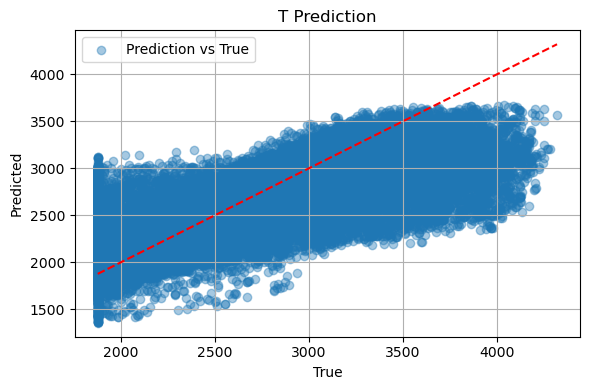

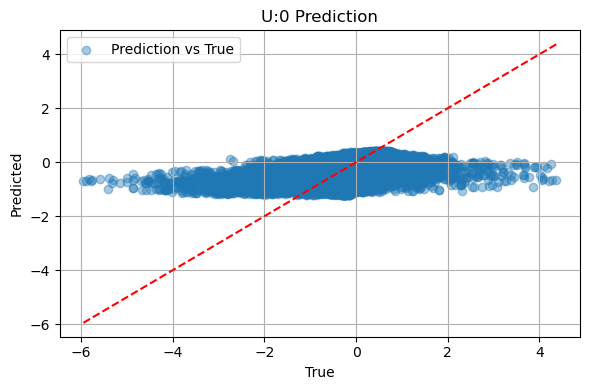

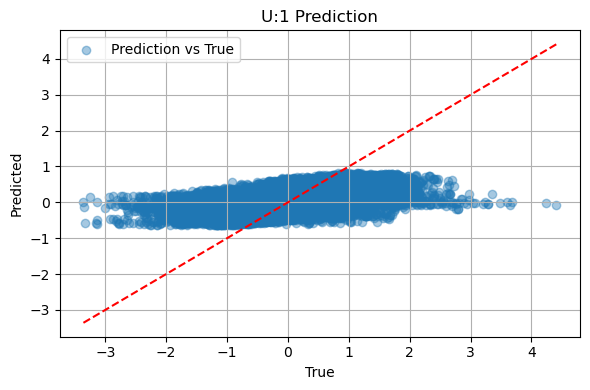

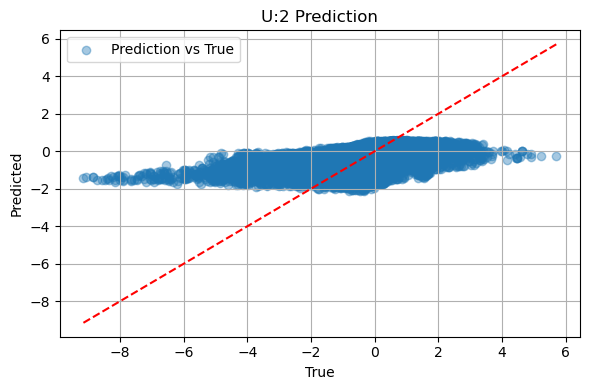

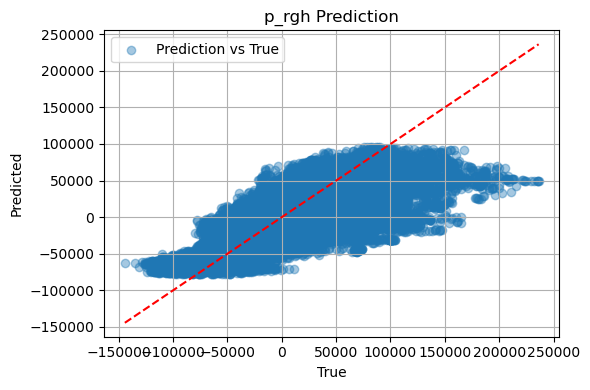

In [4]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from pyDOE import lhs
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# === Neural Network ===
class FCNN(nn.Module):
    def __init__(self, layers):
        super(FCNN, self).__init__()
        self.layers = nn.ModuleList()
        self.activation = nn.ReLU()

        for i in range(len(layers) - 1):
            linear = nn.Linear(layers[i], layers[i + 1])
            nn.init.xavier_uniform_(linear.weight)
            nn.init.zeros_(linear.bias)
            self.layers.append(linear)

    def forward(self, x):
        for i in range(len(self.layers) - 1):
            x = self.activation(self.layers[i](x))
        return self.layers[-1](x)

# === PINN Model ===
class PINN3D:
    def __init__(self, X_data, Y_data, X_f, layers, lb, ub, y_mean, y_std):
        self.lb = torch.tensor(lb, dtype=torch.float32)
        self.ub = torch.tensor(ub, dtype=torch.float32)

        self.X_data = torch.tensor(X_data, dtype=torch.float32)
        self.Y_data = torch.tensor(Y_data, dtype=torch.float32)
        self.X_f = torch.tensor(X_f, dtype=torch.float32, requires_grad=True)

        self.y_mean = torch.tensor(y_mean, dtype=torch.float32)
        self.y_std = torch.tensor(y_std, dtype=torch.float32)

        self.model = FCNN(layers)
        self.optimizer_pre = torch.optim.Adam(self.model.parameters(), lr=1e-3)
        self.optimizer_main = torch.optim.Adam(self.model.parameters(), lr=5e-4)

    def net_Y(self, X):
        X_norm = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
        return self.model(X_norm)

    def net_f(self, X):
        X = X.clone().requires_grad_(True)
        Y = self.net_Y(X)
        T, vx, vy, vz, P = torch.split(Y, 1, dim=1)
        x, y, z, t = torch.split(X, 1, dim=1)

        # Ensure outputs require grad
        T = T.requires_grad_(True)
        vx = vx.requires_grad_(True)
        vy = vy.requires_grad_(True)
        vz = vz.requires_grad_(True)
        P = P.requires_grad_(True)

        # Physical parameters
        P_laser, eta, rb, Vs = 100, 0.3, 50e-6, 0.8
        r_squared = (x - Vs * t) ** 2 + y ** 2
        Q = (2 * P_laser * eta / (np.pi * rb ** 2)) * torch.exp(-2 * r_squared / (rb ** 2))

        rho = 7000
        mu = 0.006
        cp = 500.0
        kappa = 25.0
        L = 2.5e5
        Ts, Tl = 1873.15, 1973.15

        fL = torch.clamp((T - Ts) / (Tl - Ts), 0.0, 1.0).requires_grad_(True)

        def grads(y, x):
            if not y.requires_grad:
                y = y.requires_grad_(True)
            g = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y),
                                  retain_graph=True, create_graph=True, allow_unused=True)[0]
            return g if g is not None else torch.zeros_like(x)

        # First derivatives
        dvx_dx = grads(vx, x); dvx_dy = grads(vx, y); dvx_dz = grads(vx, z); dvx_dt = grads(vx, t)
        dvy_dx = grads(vy, x); dvy_dy = grads(vy, y); dvy_dz = grads(vy, z); dvy_dt = grads(vy, t)
        dvz_dx = grads(vz, x); dvz_dy = grads(vz, y); dvz_dz = grads(vz, z); dvz_dt = grads(vz, t)
        dP_dx = grads(P, x); dP_dy = grads(P, y); dP_dz = grads(P, z)
        dT_dx = grads(T, x); dT_dy = grads(T, y); dT_dz = grads(T, z); dT_dt = grads(T, t)
        dfL_dx = grads(fL, x); dfL_dy = grads(fL, y); dfL_dz = grads(fL, z); dfL_dt = grads(fL, t)

        # Second derivatives
        d2vx_dx2 = grads(dvx_dx, x); d2vx_dy2 = grads(dvx_dy, y); d2vx_dz2 = grads(dvx_dz, z)
        d2vy_dx2 = grads(dvy_dx, x); d2vy_dy2 = grads(dvy_dy, y); d2vy_dz2 = grads(dvy_dz, z)
        d2vz_dx2 = grads(dvz_dx, x); d2vz_dy2 = grads(dvz_dy, y); d2vz_dz2 = grads(dvz_dz, z)
        d2T_dx2 = grads(dT_dx, x); d2T_dy2 = grads(dT_dy, y); d2T_dz2 = grads(dT_dz, z)

        # Laplacians and divergence
        lap_vx = d2vx_dx2 + d2vx_dy2 + d2vx_dz2
        lap_vy = d2vy_dx2 + d2vy_dy2 + d2vy_dz2
        lap_vz = d2vz_dx2 + d2vz_dy2 + d2vz_dz2
        lap_T = d2T_dx2 + d2T_dy2 + d2T_dz2
        div_u = dvx_dx + dvy_dy + dvz_dz

        # Physics equations (corrected formulations)
        mom_x = rho * (dvx_dt + vx * dvx_dx + vy * dvx_dy + vz * dvx_dz) + dP_dx - mu * lap_vx
        mom_y = rho * (dvy_dt + vx * dvy_dx + vy * dvy_dy + vz * dvy_dz) + dP_dy - mu * lap_vy
        mom_z = rho * (dvz_dt + vx * dvz_dx + vy * dvz_dy + vz * dvz_dz) + dP_dz - mu * lap_vz

        energy = (rho * cp * (dT_dt + vx * dT_dx + vy * dT_dy + vz * dT_dz) +
                 rho * L * (dfL_dt + vx * dfL_dx + vy * dfL_dy + vz * dfL_dz) -
                 kappa * lap_T - Q)

        return mom_x**2 + mom_y**2 + mom_z**2, div_u**2, energy**2

    def train_pre(self, nIter):
        self.model.train()
        for it in range(nIter):
            self.optimizer_pre.zero_grad()
            pred = self.net_Y(self.X_data)
            loss = torch.mean((pred - self.Y_data) ** 2)
            loss.backward()
            self.optimizer_pre.step()
            if it % 10 == 0:
                print(f"Pretrain Iter {it}, Loss: {loss.item():.4e}")

    def train_main(self, nIter):
        self.model.train()
        for it in range(nIter):
            self.optimizer_main.zero_grad()
            mom, div, energy = self.net_f(self.X_f)
            loss = (
                0.5 * torch.mean(mom) +
                0.1 * torch.mean(div) +
                0.01 * torch.mean(energy)
            )
            loss.backward()
            self.optimizer_main.step()
            if it % 10 == 0:
                print(f"Maintrain Iter {it}, Loss: {loss.item():.4e}")

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            pred_norm = self.net_Y(torch.tensor(X, dtype=torch.float32))
            return pred_norm * self.y_std + self.y_mean

            
# === Load and Normalize Data ===
# merged_df = pd.read_excel("your_data.xlsx")  # Replace with actual
data = merged_df

X_data = data[["Points:0", "Points:1", "Points:2", "Time"]].values
Y_data = data[["T", "U:0", "U:1", "U:2", "p_rgh"]].values

# Normalize outputs
Y_mean = Y_data.mean(axis=0)
Y_std = Y_data.std(axis=0)
Y_data_norm = (Y_data - Y_mean) / Y_std

lb = X_data.min(axis=0)
ub = X_data.max(axis=0)

# Collocation points
N_f = 100000
X_f = lb + (ub - lb) * lhs(4, N_f)

# Train the model
layers = [4, 256, 256, 256, 256, 5]
model = PINN3D(X_data, Y_data_norm, X_f, layers, lb, ub, Y_mean, Y_std)

model.train_pre(100)
model.train_main(500)

# === Evaluation ===
Y_pred_norm = model.net_Y(torch.tensor(X_data, dtype=torch.float32)).detach().numpy()
Y_pred = Y_pred_norm * Y_std + Y_mean

# True values
Y_true = Y_data

# Compute metrics
mae = mean_absolute_error(Y_true, Y_pred, multioutput='raw_values')
mse = mean_squared_error(Y_true, Y_pred, multioutput='raw_values')
r2 = r2_score(Y_true, Y_pred, multioutput='raw_values')

columns = ["T", "U:0", "U:1", "U:2", "p_rgh"]

print("\nEvaluation Metrics:")
for i, col in enumerate(columns):
    print(f"{col}: MAE={mae[i]:.4f}, MSE={mse[i]:.4f}, R²={r2[i]:.4f}")

# === Plot
for i, col in enumerate(columns):
    plt.figure(figsize=(6, 4))
    plt.scatter(Y_true[:, i], Y_pred[:, i], alpha=0.4, label='Prediction vs True')
    plt.plot([Y_true[:, i].min(), Y_true[:, i].max()],
             [Y_true[:, i].min(), Y_true[:, i].max()], 'r--')
    plt.title(f"{col} Prediction")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


Starting pretraining...
Pretrain 0/200, Loss: 1.0452e+00
Pretrain 100/200, Loss: 8.3401e-01

Starting main training...
Iter 0/500, Loss: 7.1154e-01 (Data: 7.0119e-01, Phys: 1.0347e-02), LR: 1.00e-03
Iter 100/500, Loss: 5.9344e-01 (Data: 5.8309e-01, Phys: 1.0347e-02), LR: 1.00e-03
Iter 200/500, Loss: 4.9968e-01 (Data: 4.8933e-01, Phys: 1.0347e-02), LR: 1.00e-03
Iter 300/500, Loss: 4.4508e-01 (Data: 4.3473e-01, Phys: 1.0347e-02), LR: 1.00e-03
Iter 400/500, Loss: 4.1205e-01 (Data: 4.0171e-01, Phys: 1.0347e-02), LR: 1.00e-03

Training complete. Best loss: 3.8729e-01

=== Evaluation Metrics ===
T:
  MAE: 77.1683
  MSE: 19472.6588
  R2: 0.8845
U:0:
  MAE: 0.1941
  MSE: 0.1076
  R2: 0.4413
U:1:
  MAE: 0.1636
  MSE: 0.0768
  R2: 0.4361
U:2:
  MAE: 0.2098
  MSE: 0.1347
  R2: 0.5894
p_rgh:
  MAE: 8735.9983
  MSE: 247583593.5509
  R2: 0.7651

Plotting predicted vs true values...


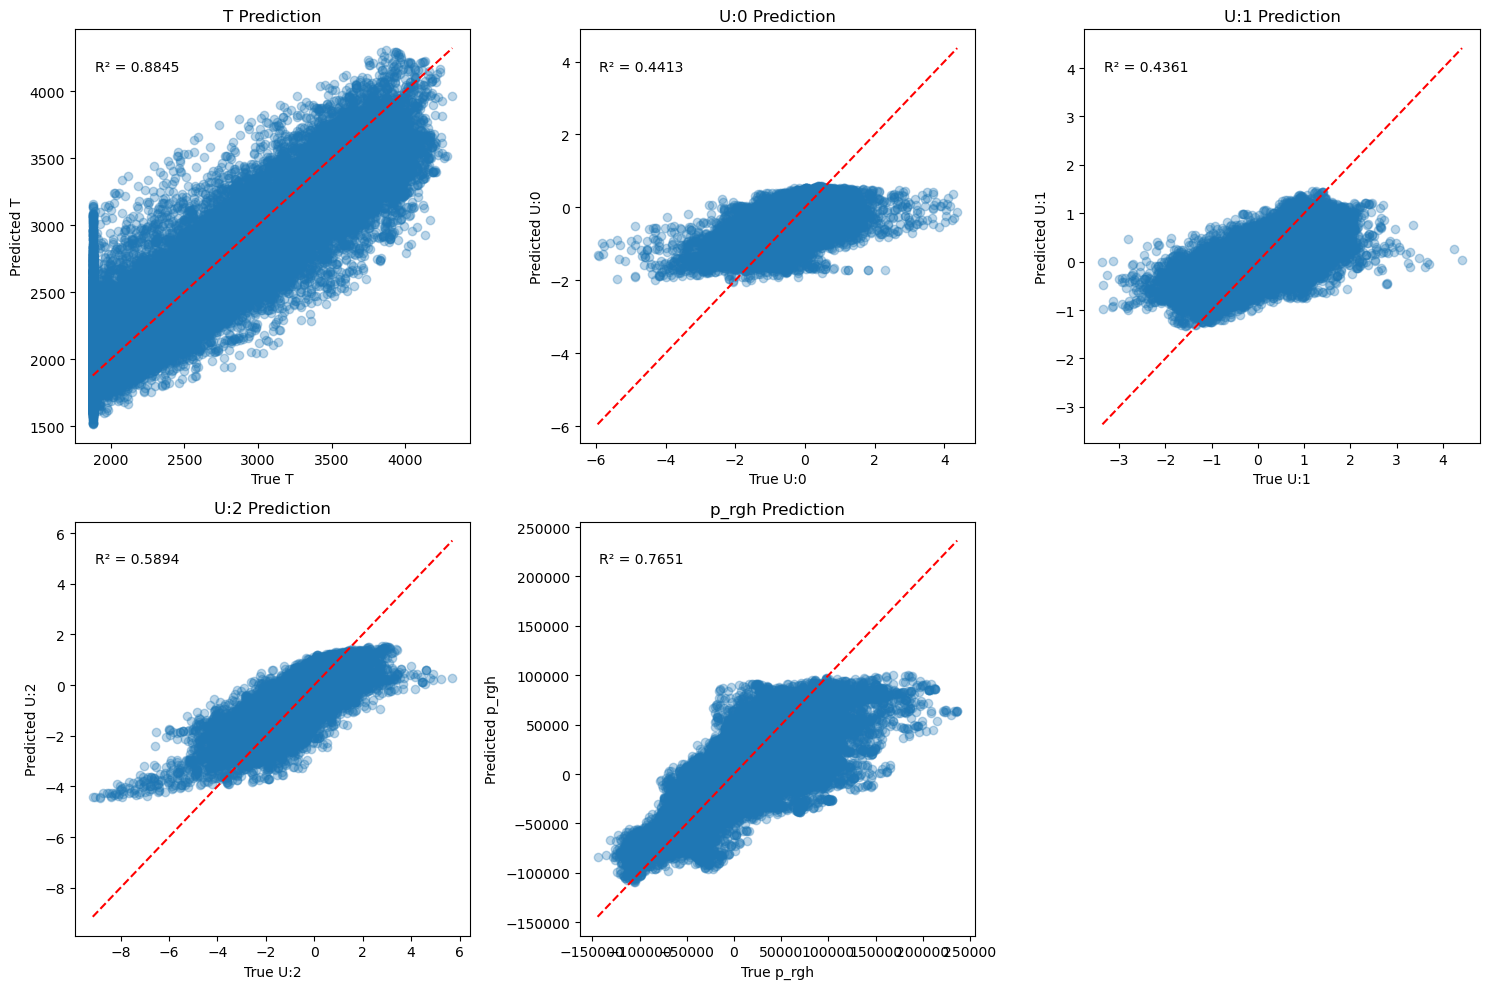


=== Melt Pool Characteristics ===
Dimensions (L×W×D): 0.000167 × 0.000126 × 0.000133 m
Max Temperature: 4423.31 K
Max Velocity: 3.6075 m/s

=== Balling Prediction Parameters ===
1. Rayleigh Number (R): 0.0002
2. Aspect Ratio (ε): 1.2561
3. Marangoni Number (Ma): 8791.4484
4. Energy Density (E): 6.3662e+10 J/m3
5. Surface Tension Force(F): 0.0014
6. Solidification Time (T_solid): 2.0857e-04 s

Balling Susceptibility Index (BSI): -7.7203
Balling prediction: UNLIKELY

BSI: -7.7203 => Balling unlikely


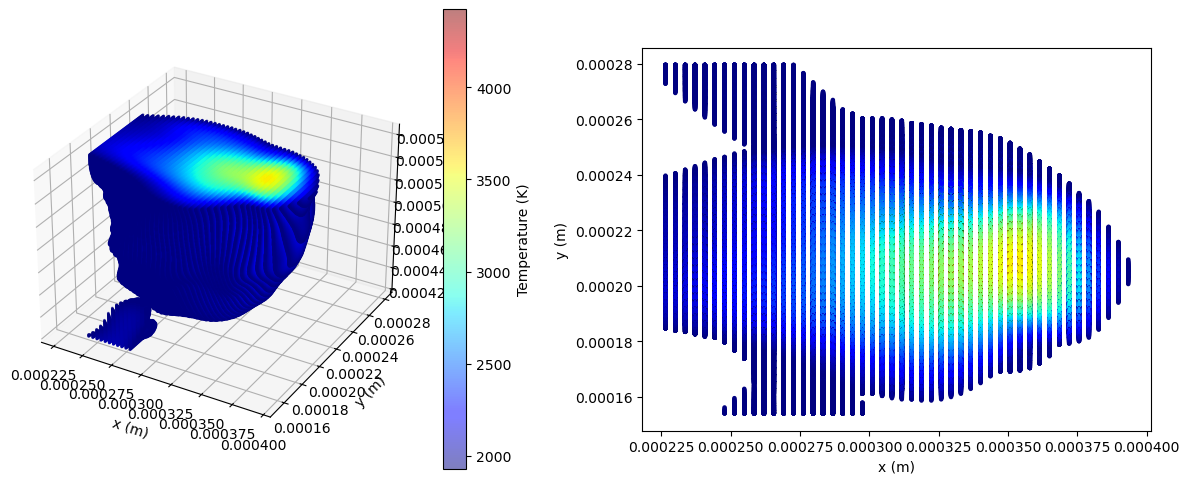

No center points found - using all points along scan direction
Isotherm positions: T40@2.29e-04m, T90@2.29e-04m, T99@2.29e-04m
Distances: L40-90=4.77e-07m, L90-99=8.59e-08m
Calculation method: convex hull
Mushy zone volume: 1.79e-12 m³
Remaining liquid volume: 5.38e-14 m³
Characteristic crack length: 37.74 μm
Solidification stress: 8.06 MPa

=== Key Process Parameters ===
1. Cooling rate: 4.24e+06 K/s
2. Thermal gradient to growth rate ratio: 1.35e+07 K·s/m
3. Vulnerable-to-relaxation time ratio: 0.180
4. Solidification stress: 8.06 MPa (characteristic length: 37.74 μm)

=== Cracking Susceptibility Analysis ===
Input values:
σ (stress): 8.06 MPa
β (relax ratio): 0.180
ε (G/R ratio): 1.35e+01 K·s/mm²
τ (cooling rate): 4.24e+06 K/s

CSI = 0.783 => Cracking likely


In [17]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from pyDOE import lhs
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.spatial import ConvexHull
from scipy.stats import gaussian_kde

# Global storage for predictions
global_predictions = {}

# === Neural Network Architecture ===
class FCNN(nn.Module):
    def __init__(self, layers):
        super(FCNN, self).__init__()
        self.layers = nn.ModuleList()
        self.activation = nn.Tanh()

        for i in range(len(layers) - 1):
            linear = nn.Linear(layers[i], layers[i + 1])
            nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            self.layers.append(linear)

    def forward(self, x):
        for i in range(len(self.layers) - 1):
            x = self.activation(self.layers[i](x))
        return self.layers[-1](x)

# === Physics-Informed Neural Network ===
class PINN3D:
    def __init__(self, X_data, Y_data, X_f, layers, lb, ub, y_mean, y_std):
        self.lb = torch.tensor(lb, dtype=torch.float32)
        self.ub = torch.tensor(ub, dtype=torch.float32)
        self.X_data = torch.tensor(X_data, dtype=torch.float32)
        self.Y_data = torch.tensor(Y_data, dtype=torch.float32)
        self.X_f = torch.tensor(X_f, dtype=torch.float32, requires_grad=True)
        self.y_mean = torch.tensor(y_mean, dtype=torch.float32)
        self.y_std = torch.tensor(y_std, dtype=torch.float32)
        self.model = FCNN(layers)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-3)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=50)

    def net_Y(self, X):
        X_norm = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
        return self.model(X_norm)

    def grads(self, y, x):
        if not x.requires_grad:
            x.requires_grad_(True)
        if y.grad_fn is None:
            y = y.clone().requires_grad_(True)
        g = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y),
                              retain_graph=True, create_graph=True, 
                              allow_unused=True)[0]
        return g if g is not None else torch.zeros_like(x)

    def net_f(self, X):
        X.requires_grad_(True)
        Y = self.net_Y(X)
        
        # Split outputs and inputs
        T = Y[:, 0:1]
        vx = Y[:, 1:2]
        vy = Y[:, 2:3]
        vz = Y[:, 3:4]
        P = Y[:, 4:5]
        x = X[:, 0:1]
        y = X[:, 1:2]
        z = X[:, 2:3]
        t = X[:, 3:4]

        # Physical parameters
        P_laser = 100
        eta = 0.3
        rb = 50e-6
        Vs = 0.8
        rho = 4430
        mu = 0.004
        cp = 525.0
        kappa = 29.0
        L = 2.84e4
        Ts = 1878
        Tl = 1928

        # Physics equations
        r_squared = (x - Vs * t)**2 + y**2
        Q = (2 * P_laser * eta / (np.pi * rb**2)) * torch.exp(-2 * r_squared / rb**2)
        fL = torch.clamp((T - Ts) / (Tl - Ts), 0.0, 1.0)

        # First derivatives
        dvx_dx = self.grads(vx, x); dvx_dy = self.grads(vx, y)
        dvx_dz = self.grads(vx, z); dvx_dt = self.grads(vx, t)
        dvy_dx = self.grads(vy, x); dvy_dy = self.grads(vy, y)
        dvy_dz = self.grads(vy, z); dvy_dt = self.grads(vy, t)
        dvz_dx = self.grads(vz, x); dvz_dy = self.grads(vz, y)
        dvz_dz = self.grads(vz, z); dvz_dt = self.grads(vz, t)
        dT_dx = self.grads(T, x); dT_dy = self.grads(T, y)
        dT_dz = self.grads(T, z); dT_dt = self.grads(T, t)
        dP_dx = self.grads(P, x); dP_dy = self.grads(P, y); dP_dz = self.grads(P, z)
        dfL_dx = self.grads(fL, x); dfL_dy = self.grads(fL, y)
        dfL_dz = self.grads(fL, z); dfL_dt = self.grads(fL, t)

        # Second derivatives
        def second_grad(first_deriv, coord):
            return self.grads(first_deriv, coord)
        
        d2vx_dx2 = second_grad(dvx_dx, x); d2vx_dy2 = second_grad(dvx_dy, y); d2vx_dz2 = second_grad(dvx_dz, z)
        d2vy_dx2 = second_grad(dvy_dx, x); d2vy_dy2 = second_grad(dvy_dy, y); d2vy_dz2 = second_grad(dvy_dz, z)
        d2vz_dx2 = second_grad(dvz_dx, x); d2vz_dy2 = second_grad(dvz_dy, y); d2vz_dz2 = second_grad(dvz_dz, z)
        d2T_dx2 = second_grad(dT_dx, x); d2T_dy2 = second_grad(dT_dy, y); d2T_dz2 = second_grad(dT_dz, z)

        # Governing equations
        div_u = dvx_dx + dvy_dy + dvz_dz
        lap_vx = d2vx_dx2 + d2vx_dy2 + d2vx_dz2
        lap_vy = d2vy_dx2 + d2vy_dy2 + d2vy_dz2
        lap_vz = d2vz_dx2 + d2vz_dy2 + d2vz_dz2
        
        mom_x = rho * (dvx_dt + vx*dvx_dx + vy*dvx_dy + vz*dvx_dz) + dP_dx - mu*lap_vx
        mom_y = rho * (dvy_dt + vx*dvy_dx + vy*dvy_dy + vz*dvy_dz) + dP_dy - mu*lap_vy
        mom_z = rho * (dvz_dt + vx*dvz_dx + vy*dvz_dy + vz*dvz_dz) + dP_dz - mu*lap_vz
        
        lap_T = d2T_dx2 + d2T_dy2 + d2T_dz2
        energy = (rho * cp * (dT_dt + vx*dT_dx + vy*dT_dy + vz*dT_dz) + 
                 rho * L * (dfL_dt + vx*dfL_dx + vy*dfL_dy + vz*dfL_dz) - 
                 kappa*lap_T - Q)
        
        return mom_x**2 + mom_y**2 + mom_z**2, div_u**2, energy**2

    def train(self, nIter_pre, nIter_main):
        best_loss = float('inf')
        
        print("Starting pretraining...")
        for it in range(nIter_pre):
            self.optimizer.zero_grad()
            pred = self.net_Y(self.X_data)
            loss = torch.mean((pred - self.Y_data)**2)
            loss.backward()
            self.optimizer.step()
            
            if it % 100 == 0:
                print(f"Pretrain {it}/{nIter_pre}, Loss: {loss.item():.4e}")
        
        print("\nStarting main training...")
        for it in range(nIter_main):
            self.optimizer.zero_grad()
            
            pred_data = self.net_Y(self.X_data)
            loss_data = torch.mean((pred_data - self.Y_data)**2)
            
            mom, div, energy = self.net_f(self.X_f)
            loss_phys = (0.5*torch.mean(mom) + 0.1*torch.mean(div) + 0.01*torch.mean(energy))
            
            loss = loss_data + loss_phys
            loss.backward()
            self.optimizer.step()
            self.scheduler.step(loss)
            
            if loss.item() < best_loss:
                best_loss = loss.item()
                torch.save(self.model.state_dict(), 'best_model.pth')
            
            if it % 100 == 0:
                lr = self.optimizer.param_groups[0]['lr']
                print(f"Iter {it}/{nIter_main}, Loss: {loss.item():.4e} "
                      f"(Data: {loss_data.item():.4e}, Phys: {loss_phys.item():.4e}), LR: {lr:.2e}")
        
        self.model.load_state_dict(torch.load('best_model.pth'))
        print(f"\nTraining complete. Best loss: {best_loss:.4e}")

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            pred_norm = self.net_Y(torch.tensor(X, dtype=torch.float32))
            return pred_norm * self.y_std + self.y_mean

def analyze_melt_pool(model, lb, ub, t0=0.00013, scan_speed=0.8, resolution=300):
    global global_predictions
    
    x = np.linspace(lb[0], ub[0], resolution)
    y = np.linspace(lb[1], ub[1], resolution)
    z = np.linspace(lb[2], ub[2], resolution)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    
    X_flat = X.flatten()
    Y_flat = Y.flatten()
    Z_flat = Z.flatten()
    T_flat = np.full_like(X_flat, t0)
    X_infer = np.column_stack((X_flat, Y_flat, Z_flat, T_flat))
    
    batch_size = 10000
    predictions = []
    for i in range(0, len(X_infer), batch_size):
        predictions.append(model.predict(X_infer[i:i+batch_size]))
    pred = np.vstack(predictions)
    
    global_predictions = {
        'T_pred': pred[:, 0],
        'vx_pred': pred[:, 1],
        'vy_pred': pred[:, 2],
        'vz_pred': pred[:, 3],
        'P_pred': pred[:, 4],
        'X_infer': X_infer,
        'vmag': np.sqrt(pred[:,1]**2 + pred[:,2]**2 + pred[:,3]**2)
    }
    
    melt_mask = global_predictions['T_pred'] > 1928
    if not np.any(melt_mask):
        print("Warning: No melt pool detected - checking with lower threshold (1900K)")
        melt_mask = global_predictions['T_pred'] > 1900
    
    if not np.any(melt_mask):
        print("Warning: Still no melt pool detected - checking with even lower threshold (1878K)")
        melt_mask = global_predictions['T_pred'] > 1878
    
    if not np.any(melt_mask):
        print("Error: No melt pool detected even at solidus temperature")
        plt.figure(figsize=(10,6))
        plt.hist(global_predictions['T_pred'], bins=50)
        plt.xlabel('Temperature (K)')
        plt.ylabel('Count')
        plt.title('Predicted Temperature Distribution')
        plt.axvline(x=1878, color='r', linestyle='--', label='Solidus Temp')
        plt.legend()
        plt.show()
        return global_predictions
    
    melt_points = global_predictions['X_infer'][melt_mask]
    melt_x, melt_y, melt_z = melt_points[:,0], melt_points[:,1], melt_points[:,2]
    
    depth = melt_z.max() - melt_z.min()
    width = melt_y.max() - melt_y.min()
    length = melt_x.max() - melt_x.min()
    max_temp = global_predictions['T_pred'][melt_mask].max()
    max_vel = global_predictions['vmag'][melt_mask].max()
    
    print("\n=== Melt Pool Characteristics ===")
    print(f"Dimensions (L×W×D): {length:.6f} × {width:.6f} × {depth:.6f} m")
    print(f"Max Temperature: {max_temp:.2f} K")
    print(f"Max Velocity: {max_vel:.4f} m/s")
    
    E = 100 / (np.pi*(25e-6)**2 * scan_speed)
    R = 9.81*length / (scan_speed - max_vel)**2
    epsilon = length/depth
    F = 1.52*np.pi*(length + width)
    T_solid = length/scan_speed
    Ma = 0.00026*length*(max_temp - 1878)/(0.004*3.14e-6)
    
    BSI = 0.65 + 0.72*R + 0.049*epsilon - 0.00093*Ma - 0.0019*(E/1e9) - 96*F - 4.5*T_solid
    # Print all balling parameters
    print("\n=== Balling Prediction Parameters ===")
    print(f"1. Richardson Number (R): {R:.4f}")
    print(f"2. Aspect Ratio (ε): {epsilon:.4f}")
    print(f"3. Marangoni Number (Ma): {Ma:.4f}")
    print(f"4. Energy Density (E): {E:.4e} J/m3")
    print(f"5. Surface Tension Force(F): {F:.4f}")
    print(f"6. Solidification Time (T_solid): {T_solid:.4e} s")
    print(f"\nBalling Susceptibility Index (BSI): {BSI:.4f}")
    print(f"Balling prediction: {'LIKELY' if BSI > 0.5 else 'UNLIKELY'}")
    
    print(f"\nBSI: {BSI:.4f} => Balling {'likely' if BSI>0.5 else 'unlikely'}")
    
    fig = plt.figure(figsize=(12,5))
    
    ax1 = fig.add_subplot(121, projection='3d')
    sc = ax1.scatter(melt_x, melt_y, melt_z, c=global_predictions['T_pred'][melt_mask], 
                    cmap='jet', s=1, alpha=0.5)
    ax1.set_xlabel('x (m)'); ax1.set_ylabel('y (m)'); ax1.set_zlabel('z (m)')
    plt.colorbar(sc, ax=ax1, label='Temperature (K)')
    
    ax2 = fig.add_subplot(122)
    z_mid = lb[2] + (ub[2]-lb[2])/2
    mask = (melt_z >= z_mid-0.0001) & (melt_z <= z_mid+0.0001)
    ax2.scatter(melt_x[mask], melt_y[mask], c=global_predictions['T_pred'][melt_mask][mask], 
               cmap='jet', s=5)
    ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    return global_predictions

def plot_predicted_vs_true(Y_true, Y_pred, columns):
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(columns):
        plt.subplot(2, 3, i+1)
        plt.scatter(Y_true[:, i], Y_pred[:, i], alpha=0.3)
        plt.plot([Y_true[:, i].min(), Y_true[:, i].max()], 
                 [Y_true[:, i].min(), Y_true[:, i].max()], 'r--')
        plt.xlabel(f'True {col}')
        plt.ylabel(f'Predicted {col}')
        plt.title(f'{col} Prediction')
        
        r2 = r2_score(Y_true[:, i], Y_pred[:, i])
        plt.text(0.05, 0.9, f'R² = {r2:.4f}', transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()

def calculate_process_parameters(global_predictions, lb, ub):
    T_pred = global_predictions['T_pred']
    vx_pred = global_predictions['vx_pred']
    vy_pred = global_predictions['vy_pred']
    vz_pred = global_predictions['vz_pred']
    X_infer = global_predictions['X_infer']
    
    T_sol = 1878
    T_liq = 1928
    E = 110e9
    gamma_S = 1.5

    def calculate_cooling_rate():
        melt_mask = T_pred > T_sol
        if not np.any(melt_mask):
            print("No melt pool detected for cooling rate calculation")
            return np.nan
        
        melt_points = X_infer[melt_mask]
        melt_temps = T_pred[melt_mask]
        melt_vel = np.column_stack([vx_pred[melt_mask], vy_pred[melt_mask], vz_pred[melt_mask]])
        
        max_x = melt_points[:,0].max()
        trailing_mask = melt_points[:,0] > (0.95 * max_x)
        
        if not np.any(trailing_mask):
            return np.nan
        
        trailing_points = melt_points[trailing_mask]
        trailing_temps = melt_temps[trailing_mask]
        trailing_vel = melt_vel[trailing_mask]
        
        dx = (ub[0] - lb[0]) / 100
        dy = (ub[1] - lb[1]) / 100
        dz = (ub[2] - lb[2]) / 100
        
        dT_dx = np.gradient(trailing_temps, dx)
        dT_dy = np.gradient(trailing_temps, dy)
        dT_dz = np.gradient(trailing_temps, dz)
        
        cooling_rates = -np.sum(trailing_vel * np.column_stack([dT_dx, dT_dy, dT_dz]), axis=1)
        return np.mean(np.abs(cooling_rates))

    def calculate_gradient_ratio():
        solid_mask = (T_pred > T_sol-50) & (T_pred < T_sol+50)
        if not np.any(solid_mask):
            print("No solidification front detected")
            return np.nan
        
        solid_points = X_infer[solid_mask]
        solid_temps = T_pred[solid_mask]
        solid_vel = np.column_stack([vx_pred[solid_mask], vy_pred[solid_mask], vz_pred[solid_mask]])
        
        dx = (ub[0] - lb[0]) / 100
        dy = (ub[1] - lb[1]) / 100
        dz = (ub[2] - lb[2]) / 100
        
        dT_dx = np.gradient(solid_temps, dx)
        dT_dy = np.gradient(solid_temps, dy)
        dT_dz = np.gradient(solid_temps, dz)
        
        G = np.sqrt(dT_dx**2 + dT_dy**2 + dT_dz**2)
        n = np.column_stack([dT_dx, dT_dy, dT_dz])
        n = n / (np.linalg.norm(n, axis=1, keepdims=True) + 1e-12)
        R = np.sum(solid_vel * n, axis=1)
        epsilon = np.median(G / (np.abs(R) + 1e-12))
        return epsilon

    def calculate_relaxation_ratio():
        try:
            T40 = T_sol + 0.6*(T_liq - T_sol)
            T90 = T_sol + 0.1*(T_liq - T_sol)
            T99 = T_sol + 0.01*(T_liq - T_sol)
            
            center_threshold = min((ub[1]-lb[1])*0.2, (ub[2]-lb[2])*0.2)
            center_mask = (np.abs(X_infer[:,1]) < center_threshold) & \
                         (np.abs(X_infer[:,2]) < center_threshold)
            
            if not np.any(center_mask):
                print("No center points found - using all points along scan direction")
                center_mask = np.ones_like(X_infer[:,0], dtype=bool)
            
            center_points = X_infer[center_mask]
            center_temps = T_pred[center_mask]
            sort_idx = np.argsort(center_points[:,0])
            sorted_x = center_points[sort_idx,0]
            sorted_T = center_temps[sort_idx]
            
            try:
                unique_x, unique_idx = np.unique(sorted_x, return_index=True)
                unique_T = sorted_T[unique_idx]
                
                crossings = []
                for T_thresh in [T40, T90, T99]:
                    cross_idx = np.where(unique_T > T_thresh)[0]
                    if len(cross_idx) == 0:
                        print(f"No crossing found for T={T_thresh:.1f}K")
                        return np.nan
                    
                    if cross_idx[0] > 0:
                        x0, x1 = unique_x[cross_idx[0]-1], unique_x[cross_idx[0]]
                        T0, T1 = unique_T[cross_idx[0]-1], unique_T[cross_idx[0]]
                        t = (T_thresh - T0)/(T1 - T0)
                        x_cross = x0 + t*(x1 - x0)
                    else:
                        x_cross = unique_x[cross_idx[0]]
                    crossings.append(x_cross)
                
                x_T40, x_T90, x_T99 = crossings
                
                L_40_90 = np.abs(x_T90 - x_T40)
                L_90_99 = np.abs(x_T99 - x_T90)
                
                if L_40_90 < 1e-10:
                    return np.nan
                    
                ratio = L_90_99 / L_40_90
                print(f"Isotherm positions: T40@{x_T40:.2e}m, T90@{x_T90:.2e}m, T99@{x_T99:.2e}m")
                print(f"Distances: L40-90={L_40_90:.2e}m, L90-99={L_90_99:.2e}m")
                return ratio
                
            except Exception as e:
                print(f"Error in isotherm calculation: {str(e)}")
                return np.nan
                
        except Exception as e:
            print(f"Error in relaxation ratio calculation: {str(e)}")
            return np.nan

    def calculate_solidification_stress():
        """
        Calculates solidification stress using the crack-length methodology from [16].
        Returns:
            sigma_c (float): Solidification stress in Pascals
            crack_length (float): Characteristic crack length in meters
        """
        try:
            # Material properties (for Ti-6Al-4V - adjust as needed)
            E = 110e9  # Young's modulus in Pa (110 GPa for Ti-6Al-4V)
            gamma_S = 0.035  # Specific surface energy in J/m² (from reference)
            
            # Define solid fraction range for final solidification stage (0.9-0.99)
            # Using fs = 0.97 as representative value (similar to AlSi10Mg in reference)
            remaining_liquid_fraction = 0.03  # 1 - 0.97
            
            # Identify mushy zone (between solidus and liquidus)
            mushy_mask = (T_pred > T_sol) & (T_pred < T_liq)
            mushy_points = X_infer[mushy_mask]
            
            if len(mushy_points) == 0:
                print("Warning: No mushy zone detected")
                return np.nan, np.nan
                
            # Calculate mushy zone volume using convex hull (most accurate)
            try:
                hull = ConvexHull(mushy_points[:, :3])  # Only spatial dimensions
                V_mushy = hull.volume
                method = "convex hull"
            except:
                # Fallback to bounding box method if convex hull fails
                ranges = (np.percentile(mushy_points[:, 0], 97.5) - 
                         np.percentile(mushy_points[:, 0], 2.5))
                V_mushy = np.prod(ranges)
                method = "percentile bounding box"
            
            # Volume of remaining liquid in final stage
            V_liquid = V_mushy * remaining_liquid_fraction
            
            # Characteristic crack length (cube root of liquid volume)
            crack_length = (V_liquid) ** (1/3)
            
            # Adjust if unrealistically small/large
            crack_length = np.clip(crack_length, 1e-6, 500e-6)  # 1-500 μm range
            
            # Solidification stress calculation (Eq. 1 from reference)
            sigma_c = np.sqrt((2 * E * gamma_S) / (np.pi * crack_length))
            
            print(f"Calculation method: {method}")
            print(f"Mushy zone volume: {V_mushy:.2e} m³")
            print(f"Remaining liquid volume: {V_liquid:.2e} m³")
            print(f"Characteristic crack length: {crack_length*1e6:.2f} μm")
            print(f"Solidification stress: {sigma_c/1e6:.2f} MPa")
            
            return sigma_c, crack_length
            
        except Exception as e:
            print(f"Error in stress calculation: {str(e)}")
            # Fallback to empirical method if primary method fails
            cooling_rate = calculate_cooling_rate()
            if not np.isnan(cooling_rate):
                # Empirical relationship for Ti-6Al-4V
                sigma_c_MPa = 0.15 * np.sqrt(cooling_rate * 1e-6) + 5.0  
                crack_length = 50e-6  # Assume 50 μm as default
                print(f"Using empirical fallback: {sigma_c_MPa:.2f} MPa (50 μm crack length)")
                return sigma_c_MPa * 1e6, crack_length
            return np.nan, np.nan
    # Calculate all parameters
    cooling_rate = calculate_cooling_rate()
    gradient_ratio = calculate_gradient_ratio()
    relaxation_ratio = calculate_relaxation_ratio()
    solidification_stress, char_length = calculate_solidification_stress()
    
    return cooling_rate, gradient_ratio, relaxation_ratio, solidification_stress, char_length

def calculate_cracking_susceptibility(sol_stress, relax_ratio, grad_ratio, cooling_rate):
    """
    Calculates Cracking Susceptibility Index (CSI) using:
    CSI = 0.182*σ + 0.135*β + 0.014*ε - 1.1e-8*τ - 0.85
    
    Where:
    σ = Solidification stress (MPa)
    β = Vulnerable-to-relaxation time ratio (unitless)
    ε = G/R ratio (K·s/mm²)
    τ = Cooling rate (K/s)
    
    Returns:
    CSI value and cracking prediction
    """
    try:
        # Convert units for G/R ratio from K·s/m² to K·s/mm²
        epsilon_mm = grad_ratio * 1e-6  # 1 m² = 1e6 mm²
        
        # Convert stress from Pa to MPa if needed
        sigma_MPa = sol_stress / 1e6 if sol_stress > 1e6 else sol_stress
        
        # Calculate CSI
        CSI = (0.182 * sigma_MPa + 
              0.135 * relax_ratio + 
              0.014 * epsilon_mm - 
              1.1e-8 * cooling_rate - 
              0.85)
        
        # Determine cracking prediction
        cracking_prediction = "likely" if CSI > 0.5 else "unlikely"
        
        print("\n=== Cracking Susceptibility Analysis ===")
        print(f"Input values:")
        print(f"σ (stress): {sigma_MPa:.2f} MPa")
        print(f"β (relax ratio): {relax_ratio:.3f}")
        print(f"ε (G/R ratio): {epsilon_mm:.2e} K·s/mm²")
        print(f"τ (cooling rate): {cooling_rate:.2e} K/s")
        print(f"\nCSI = {CSI:.3f} => Cracking {cracking_prediction}")
        
        return CSI, cracking_prediction
        
    except Exception as e:
        print(f"Error calculating CSI: {str(e)}")
        return np.nan, "undetermined"

# === Main Execution ===
if __name__ == "__main__":
    # Load data
    # merged_df = pd.read_csv('your_data.csv')  # Replace with your actual data file
    X_data = merged_df[["Points:0", "Points:1", "Points:2", "Time"]].values
    Y_data = merged_df[["T", "U:0", "U:1", "U:2", "p_rgh"]].values
    
    # Normalize
    Y_mean = Y_data.mean(axis=0)
    Y_std = Y_data.std(axis=0)
    Y_norm = (Y_data - Y_mean)/Y_std
    
    # Domain bounds
    lb = X_data.min(axis=0)
    ub = X_data.max(axis=0)
    
    # Collocation points
    N_f = 50000
    X_f = lb + (ub - lb)*lhs(4, N_f)
    
    # Initialize model
    layers = [4, 128, 128, 128, 5]  # Input dim: 4, Output dim: 5
    model = PINN3D(X_data, Y_norm, X_f, layers, lb, ub, Y_mean, Y_std)
    
    # Train
    model.train(nIter_pre=200, nIter_main=500)
    
    # Evaluate
    Y_pred = model.predict(X_data)
    print("\n=== Evaluation Metrics ===")
    for i, col in enumerate(["T", "U:0", "U:1", "U:2", "p_rgh"]):
        print(f"{col}:")
        print(f"  MAE: {mean_absolute_error(Y_data[:,i], Y_pred[:,i]):.4f}")
        print(f"  MSE: {mean_squared_error(Y_data[:,i], Y_pred[:,i]):.4f}")
        print(f"  R2: {r2_score(Y_data[:,i], Y_pred[:,i]):.4f}")
    
    # Plot predicted vs true values
    print("\nPlotting predicted vs true values...")
    plot_predicted_vs_true(Y_data, Y_pred, ["T", "U:0", "U:1", "U:2", "p_rgh"])
    
    # Analyze melt pool (stores results in global_predictions)
    melt_results = analyze_melt_pool(model, lb, ub)
    
    # Calculate and display process parameters
    cooling_rate, grad_ratio, relax_ratio, sol_stress, char_length = calculate_process_parameters(global_predictions, lb, ub)
    
    print("\n=== Key Process Parameters ===")
    print(f"1. Cooling rate: {cooling_rate:.2e} K/s")
    print(f"2. Thermal gradient to growth rate ratio: {grad_ratio:.2e} K·s/m")
    print(f"3. Vulnerable-to-relaxation time ratio: {relax_ratio:.3f}")
    if not np.isnan(sol_stress) and not np.isinf(sol_stress):
        print(f"4. Solidification stress: {sol_stress/1e6:.2f} MPa (characteristic length: {char_length*1e6:.2f} μm)")
    else:
        print("4. Solidification stress: Could not calculate")
    if (not np.isnan(sol_stress) and not np.isnan(relax_ratio) and 
        not np.isnan(grad_ratio) and not np.isnan(cooling_rate)):
        CSI, cracking_pred = calculate_cracking_susceptibility(
            sol_stress, relax_ratio, grad_ratio, cooling_rate
        )
    else:
        print("\nCannot compute CSI - missing required parameters")

In [16]:
def analyze_melt_pool(model, lb, ub, t0=0.00013, scan_speed=0.8, resolution=300):
    global global_predictions
    
    x = np.linspace(lb[0], ub[0], resolution)
    y = np.linspace(lb[1], ub[1], resolution)
    z = np.linspace(lb[2], ub[2], resolution)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    
    X_flat = X.flatten()
    Y_flat = Y.flatten()
    Z_flat = Z.flatten()
    T_flat = np.full_like(X_flat, t0)
    X_infer = np.column_stack((X_flat, Y_flat, Z_flat, T_flat))
    
    batch_size = 10000
    predictions = []
    for i in range(0, len(X_infer), batch_size):
        predictions.append(model.predict(X_infer[i:i+batch_size]))
    pred = np.vstack(predictions)
    
    global_predictions = {
        'T_pred': pred[:, 0],
        'vx_pred': pred[:, 1],
        'vy_pred': pred[:, 2],
        'vz_pred': pred[:, 3],
        'P_pred': pred[:, 4],
        'X_infer': X_infer,
        'vmag': np.sqrt(pred[:,1]**2 + pred[:,2]**2 + pred[:,3]**2)
    }
    
    melt_mask = global_predictions['T_pred'] > 1928
    if not np.any(melt_mask):
        print("Warning: No melt pool detected - checking with lower threshold (1900K)")
        melt_mask = global_predictions['T_pred'] > 1900
    
    if not np.any(melt_mask):
        print("Warning: Still no melt pool detected - checking with even lower threshold (1878K)")
        melt_mask = global_predictions['T_pred'] > 1878
    
    if not np.any(melt_mask):
        print("Error: No melt pool detected even at solidus temperature")
        plt.figure(figsize=(10,6))
        plt.hist(global_predictions['T_pred'], bins=50)
        plt.xlabel('Temperature (K)')
        plt.ylabel('Count')
        plt.title('Predicted Temperature Distribution')
        plt.axvline(x=1878, color='r', linestyle='--', label='Solidus Temp')
        plt.legend()
        plt.show()
        return global_predictions
    
    melt_points = global_predictions['X_infer'][melt_mask]
    melt_x, melt_y, melt_z = melt_points[:,0], melt_points[:,1], melt_points[:,2]
    
    depth = melt_z.max() - melt_z.min()
    width = melt_y.max() - melt_y.min()
    length = melt_x.max() - melt_x.min()
    max_temp = global_predictions['T_pred'][melt_mask].max()
    max_vel = global_predictions['vmag'][melt_mask].max()
    
    print("\n=== Melt Pool Characteristics ===")
    print(f"Dimensions (L×W×D): {length:.6f} × {width:.6f} × {depth:.6f} m")
    print(f"Max Temperature: {max_temp:.2f} K")
    print(f"Max Velocity: {max_vel:.4f} m/s")
    
    E = 100 / (np.pi*(25e-6)**2 * scan_speed)
    R = 9.81*length / (scan_speed - max_vel)**2
    epsilon = length/depth
    F = 1.52*np.pi*(length + width)
    T_solid = length/scan_speed
    Ma = 0.00026*length*(max_temp - 1878)/(0.004*3.14e-6)
    
    BSI = 0.65 + 0.72*R + 0.049*epsilon - 0.00093*Ma - 0.0019*(E/1e9) - 96*F - 4.5*T_solid
    balling_params = {
        'R': R,
        'epsilon': epsilon,
        'Ma': Ma,
        'E': E,
        'F': F,
        'T_solid': T_solid,
        'BSI': BSI
    }
    print(f"\nBSI: {BSI:.4f} => Balling {'likely' if BSI>0.5 else 'unlikely'}")
    
    
    
    return global_predictions, balling_params
melt_results, balling_params = analyze_melt_pool(model, lb, ub)
print("\n=== Balling Prediction Variables ===")
print(f"1. R (Richardson number): {balling_params['R']:.4f}")
print(f"2. ε (Aspect ratio - length/depth): {balling_params['epsilon']:.4f}")
print(f"3. Ma (Marangoni number): {balling_params['Ma']:.4f}")
print(f"4. E (Energy density): {balling_params['E']:.4f} J/m²")
print(f"5. F (Form factor): {balling_params['F']:.4f}")
print(f"6. T_solid (Solidification time): {balling_params['T_solid']:.4e} s")
print(f"\nBSI (Balling Susceptibility Index): {balling_params['BSI']:.4f}")
print(f"Balling prediction: {'likely' if balling_params['BSI'] > 0.5 else 'unlikely'}")


=== Melt Pool Characteristics ===
Dimensions (L×W×D): 0.001061 × 0.000126 × 0.000133 m
Max Temperature: 4605.37 K
Max Velocity: 3.5755 m/s

BSI: -55.3625 => Balling unlikely

=== Balling Prediction Variables ===
1. R (Richardson number): 0.0014
2. ε (Aspect ratio - length/depth): 7.9906
3. Ma (Marangoni number): 59928.9302
4. E (Energy density): 63661977236.7581 J/m²
5. F (Form factor): 0.0057
6. T_solid (Solidification time): 1.3268e-03 s

BSI (Balling Susceptibility Index): -55.3625
Balling prediction: unlikely
